In [10]:
# Data & Visualization
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Preprocessing & Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

In [11]:
# Define stock symbol and time range
stock = "GOOG"
end = datetime.now()
start = datetime(end.year - 20, end.month, end.day)

# Download historical stock data (auto_adjust=False retains 'Adj Close')
google_data = yf.download(stock, start=start, end=end, progress=False, auto_adjust=False)

# Validate data
if 'Adj Close' not in google_data.columns:
    raise ValueError("'Adj Close' column is missing. Check ticker or try again.")

Price     Adj Close        Close         High          Low         Open  \
Ticker         GOOG         GOOG         GOOG         GOOG         GOOG   
count   5033.000000  5033.000000  5033.000000  5033.000000  5033.000000   
mean      51.323533    51.544875    52.074646    51.000371    51.523632   
std       48.846594    49.022830    49.552438    48.491476    48.994978   
min        5.602863     5.629400     5.673733     5.512338     5.525539   
25%       13.636556    13.701145    13.872502    13.540995    13.699401   
50%       28.951509    29.088636    29.286594    28.905655    29.155952   
75%       71.109200    71.445999    72.026001    70.513496    71.449997   
max      207.473633   207.710007   208.699997   204.259995   204.500000   

Price         Volume  
Ticker          GOOG  
count   5.033000e+03  
mean    1.019030e+08  
std     1.315091e+08  
min     1.584340e+05  
25%     2.602600e+07  
50%     4.746600e+07  
75%     1.242279e+08  
max     1.650833e+09  
<class 'pandas.core

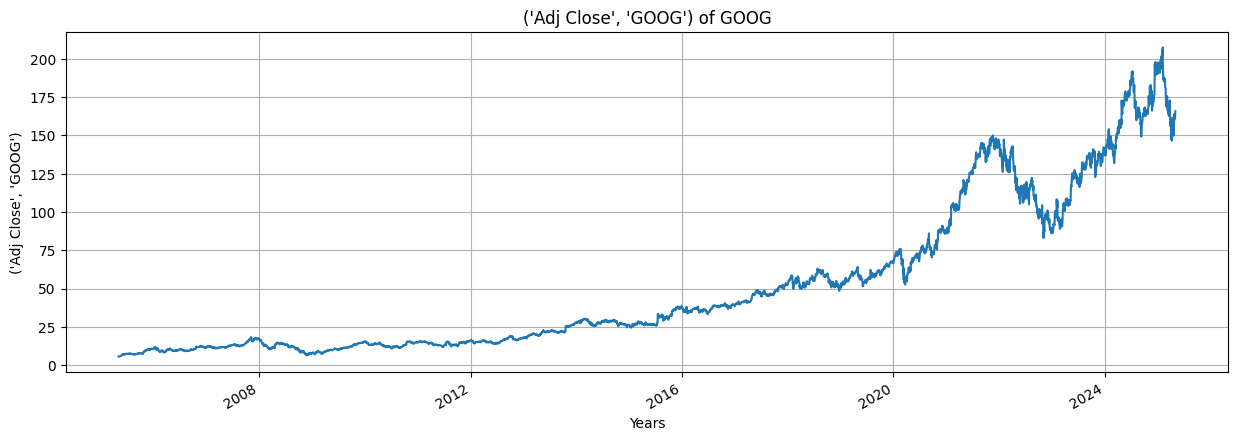

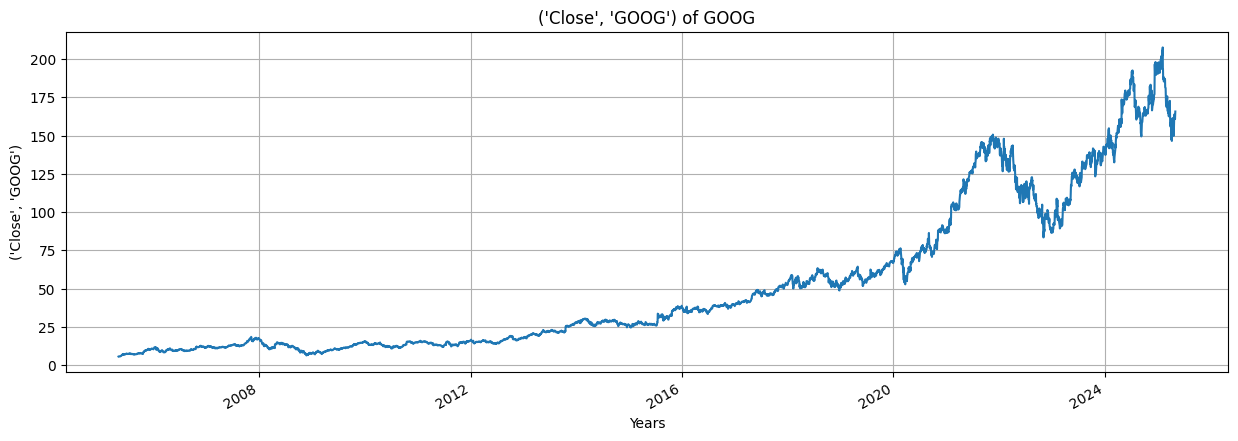

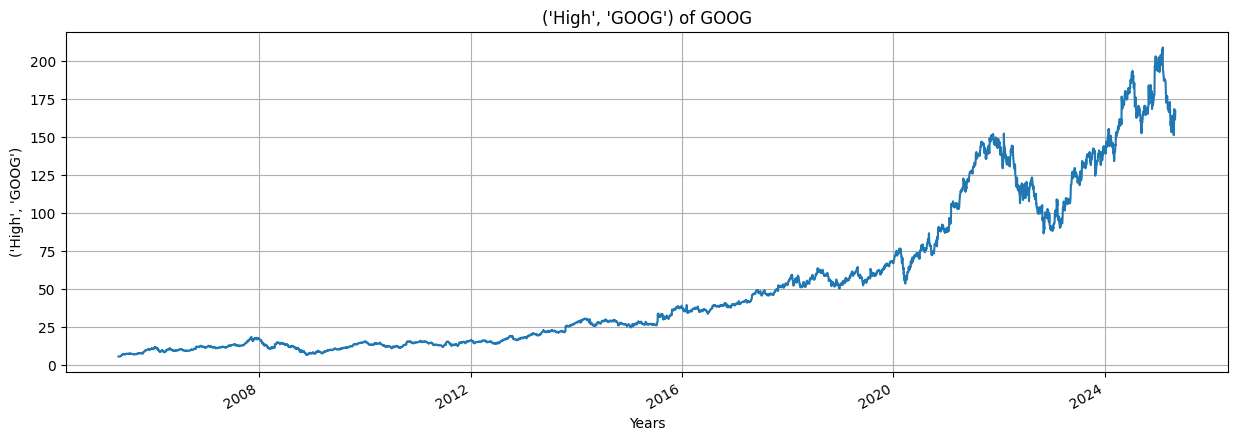

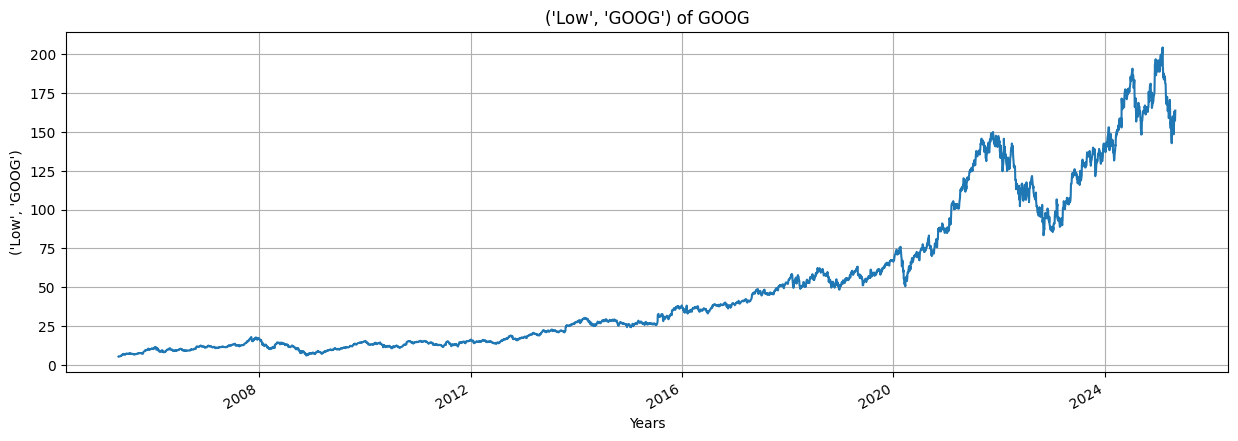

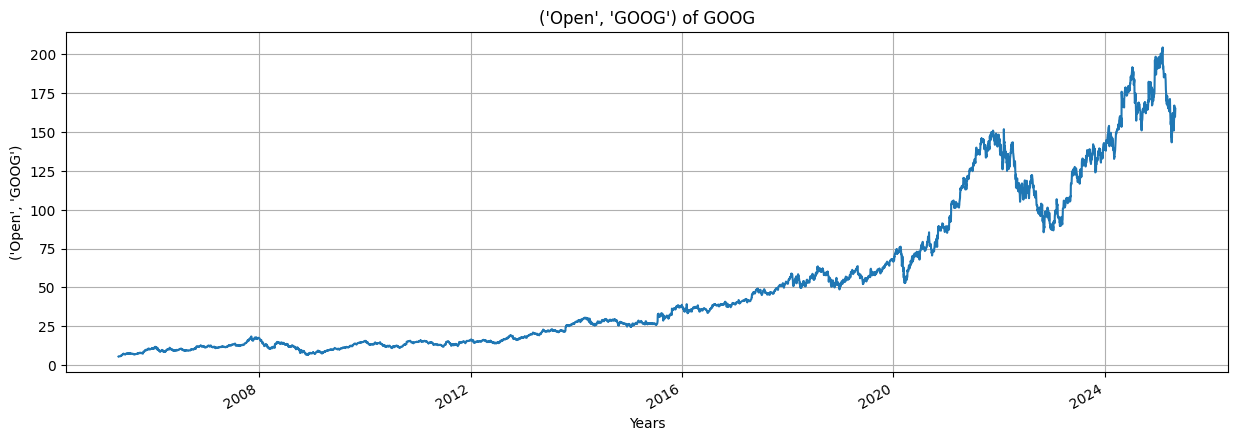

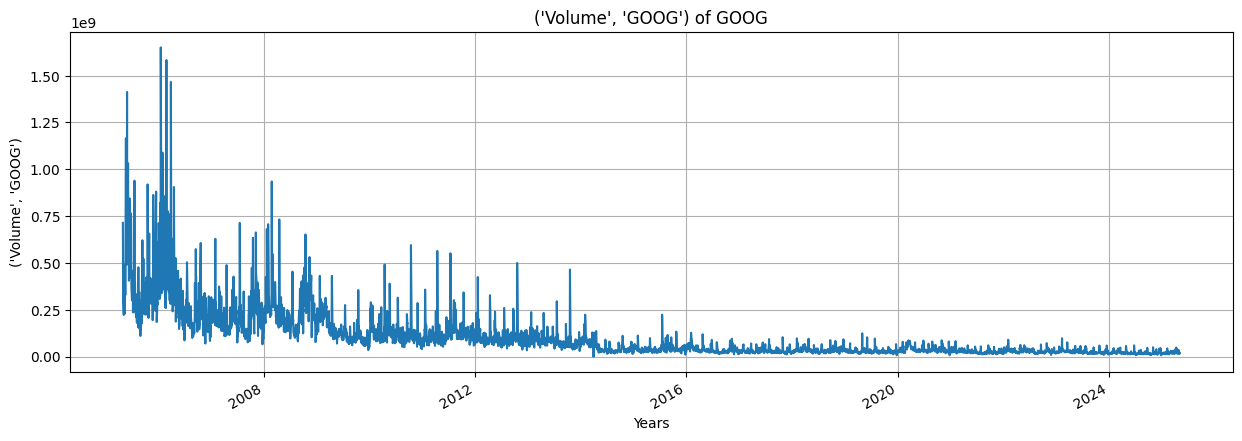

In [12]:
# Summary & missing values
print(google_data.describe())
print(google_data.info())
print(google_data.isna().sum())

# Plotting helper
def plot_graph(figsize, values, column_name):
    plt.figure(figsize=figsize)
    values.plot()
    plt.xlabel("Years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of {stock}")
    plt.grid(True)
    plt.show()

# Visualize each column
for column in google_data.columns:
    plot_graph((15, 5), google_data[column], column)

<Figure size 1500x500 with 0 Axes>

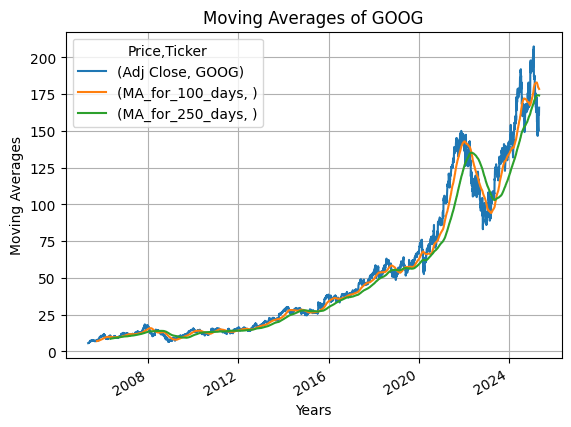

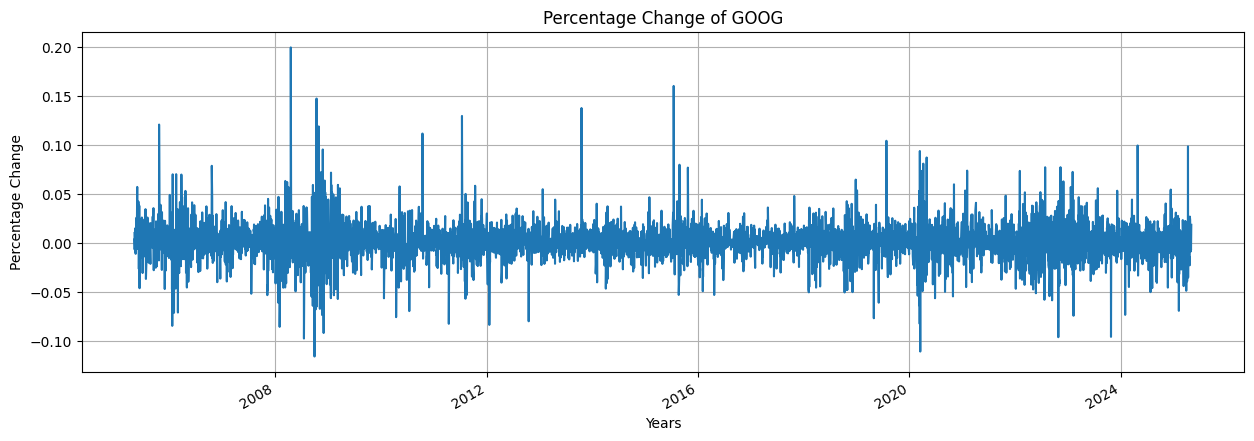

In [13]:
# Moving averages
google_data['MA_for_100_days'] = google_data['Adj Close'].rolling(100).mean()
google_data['MA_for_250_days'] = google_data['Adj Close'].rolling(250).mean()
plot_graph((15, 5), google_data[['Adj Close', 'MA_for_100_days', 'MA_for_250_days']], 'Moving Averages')

# Daily returns
google_data['percentage_change_cp'] = google_data['Adj Close'].pct_change()
plot_graph((15, 5), google_data['percentage_change_cp'], 'Percentage Change')

In [14]:
# Normalize 'Adj Close' column
Adj_close_price = google_data[['Adj Close']].dropna()
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(Adj_close_price)

# Create sequences
x_data, y_data = [], []
for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

x_data, y_data = np.array(x_data), np.array(y_data)
x_data = x_data.reshape(x_data.shape[0], x_data.shape[1], 1)

# Train-test split
split_len = int(len(x_data) * 0.7)
x_train, y_train = x_data[:split_len], y_data[:split_len]
x_test, y_test = x_data[split_len:], y_data[split_len:]


In [15]:
# LSTM model architecture
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(64),
    Dense(25),
    Dense(1)
])

# Compile and train
model.compile(optimizer='adam', loss='mean_squared_error')

# Save best model using Keras 3.x format
checkpoint = ModelCheckpoint("Latest_stock_price_model.keras", save_best_only=True)
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

model.fit(x_train, y_train, batch_size=32, epochs=10, callbacks=[early_stop, checkpoint])
model.summary()


Epoch 1/10
108/108 [==============================] - 11s 81ms/step - loss: 4.5923e-04
Epoch 2/10
108/108 [==============================] - 9s 81ms/step - loss: 2.3020e-05
Epoch 3/10
108/108 [==============================] - 9s 81ms/step - loss: 2.3370e-05
Epoch 4/10
108/108 [==============================] - 9s 80ms/step - loss: 2.2576e-05
Epoch 5/10
108/108 [==============================] - 9s 82ms/step - loss: 2.4741e-05
Epoch 6/10
108/108 [==============================] - 9s 82ms/step - loss: 2.2080e-05
Epoch 7/10
108/108 [==============================] - 9s 85ms/step - loss: 2.6539e-05
Epoch 8/10
108/108 [==============================] - 9s 83ms/step - loss: 2.2376e-05
Epoch 9/10
108/108 [==============================] - 9s 84ms/step - loss: 1.9049e-05
Epoch 10/10
108/108 [==============================] - 9s 84ms/step - loss: 1.9620e-05
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape         

In [16]:
# Predict and inverse transform
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

# RMSE calculation
rmse = np.sqrt(np.mean((inv_predictions - inv_y_test) ** 2))
print(f"RMSE: {rmse}")

47/47 [==============================] - 2s 27ms/step
RMSE: 5.223968702049829


<Figure size 1500x600 with 0 Axes>

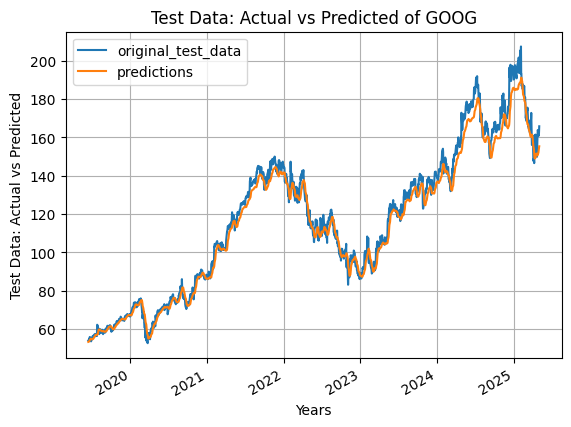

<Figure size 1500x600 with 0 Axes>

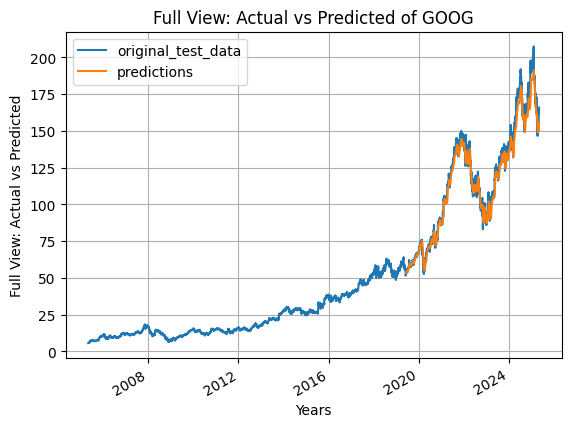

In [17]:
# Create DataFrame for plotting
ploting_data = pd.DataFrame({
    'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
}, index=google_data.index[-len(inv_y_test):])

plot_graph((15, 6), ploting_data, 'Test Data: Actual vs Predicted')

# Align index and column structure for proper concatenation
historical_data = pd.DataFrame({
    'original_test_data': Adj_close_price[:split_len + 100].values.reshape(-1),
}, index=Adj_close_price[:split_len + 100].index)

combined = pd.concat([historical_data, ploting_data], axis=0)
plot_graph((15, 6), combined, 'Full View: Actual vs Predicted')

In [18]:
# Save model and scaler
# Model is already saved using ModelCheckpoint
joblib.dump(scaler, "price_scaler.pkl")
# '''

# updated_code[:1000]  # Show the beginning of the updated code

['price_scaler.pkl']